## **0. Импорты**


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1.Выбор датасета**
### Я выбрал датасет по страховым расходам на человека. Выбран именно он, потому что немного фич, есть простор для feature engineering'a и размер датасета не особо большой (1300 строк)

In [97]:
df = pd.read_csv('data/insurance.csv')

## **2. EDA**

In [98]:
display(df.info())
display(df.describe())
display(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

*Nan'ов нет, заполнять ничего не надо. Разброс данных относительно небольшой.*

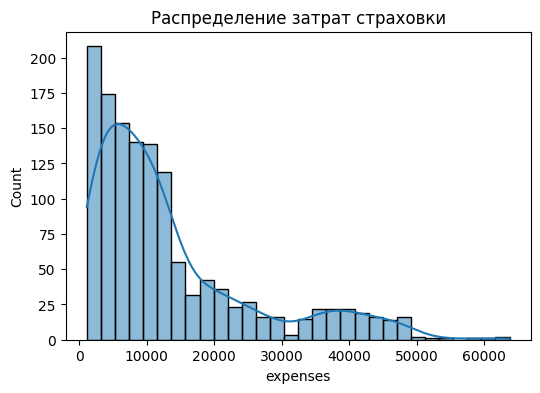

In [99]:
plt.figure(figsize=(6, 4))
sns.histplot(df['expenses'], kde=True, bins=30)
plt.title('Распределение затрат страховки')
plt.show()

*Затраты страховки - наша целовая переменная. видим два 'горба' (бимодальное распределение). Это может быть связанно с тем, что горб слева - это некурящие люди с хорошим здоровьем и ИМТ, а справа - курящие и/или имеющие проблемы со здоровьем или ИМТ.*

<Axes: xlabel='expenses', ylabel='Count'>

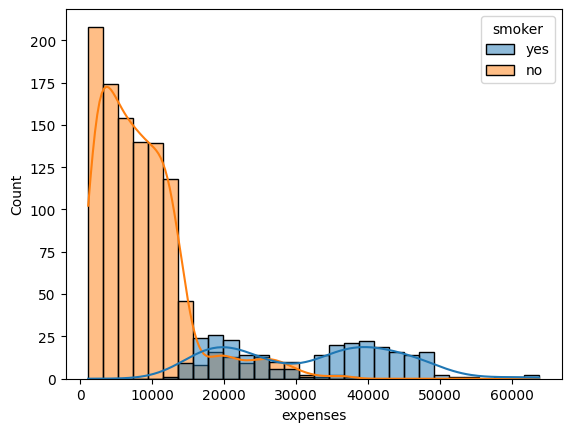

In [100]:
sns.histplot(data=df, x='expenses', hue='smoker', kde=True, bins=30)

*Подтверждаем нашу гипотезу вот таким графиком. Люди в левом горбе действительно не курят и меньше платят за страховку.*

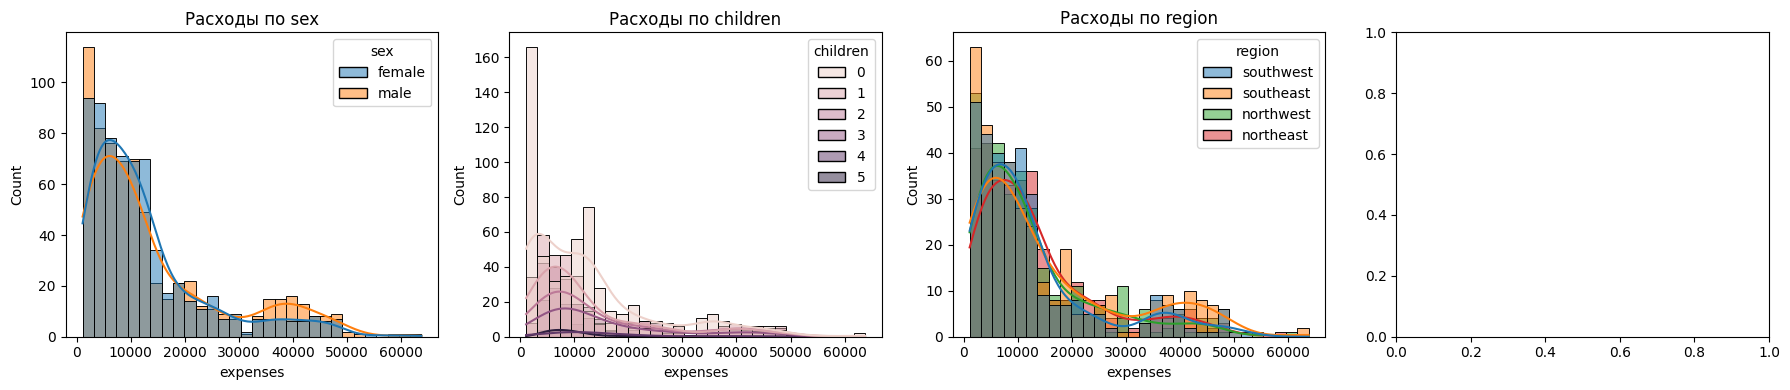

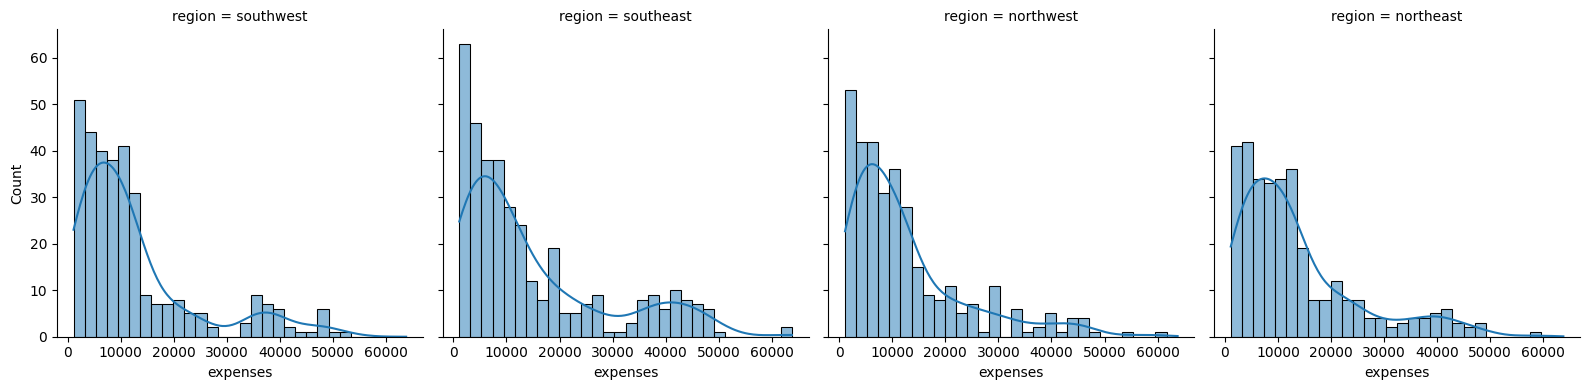

In [101]:
features = ['sex', 'children', 'region']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(features):
    sns.histplot(data=df, x='expenses', hue=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Расходы по {col}')

plt.tight_layout()
plt.show()
sns.displot(data=df, x='expenses', col='region', kde=True, height=4, aspect=1)

*После интересного наблюдения с smokers хочется посмотреть и на другие графики. Я увидел, что expenses вообще не зависит от region, поэтому его можно смело удалить!*

In [102]:
df.drop(columns=['region'], inplace=True)

*Перед тем, как построить матрицу корелляций, надо закодировать значения, тк строки она не сможет распознать.*

In [109]:
df_encoded = df.copy()

df_encoded = pd.get_dummies(data=df_encoded, columns=['sex','smoker'], drop_first=True)
df_encoded.head()

,age,bmi,children,expenses,sex_male,smoker_yes
0,19,27.9,0,16884.92,False,True
1,18,33.8,1,1725.55,True,False
2,28,33.0,3,4449.46,True,False
3,33,22.7,0,21984.47,True,False
4,32,28.9,0,3866.86,True,False


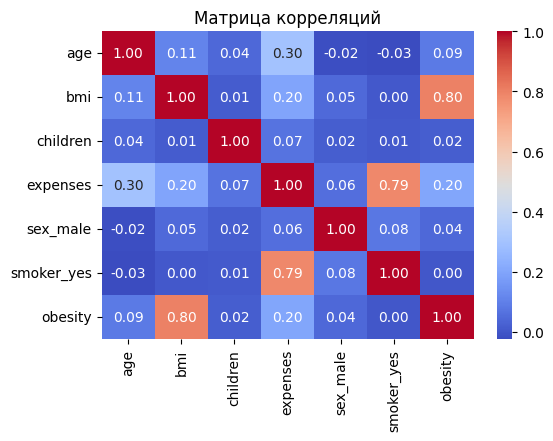

In [108]:
plt.figure(figsize=(6, 4))

numeric_df = df_encoded.select_dtypes(include=['int64', 'float64','bool'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()